# Inspect Winkler et al., 2021 Data

In [1]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import pyreadr
import pandas as pd

base_dir = "/Users/jakobwerkgarner/code/mt_dsnow"

os.chdir(base_dir)


In [2]:
import os
import pandas as pd

# load station names
meta = pd.read_csv(
    "calibration/calibration_data/raw_data/dsnow/Win21_calib/meta_Win21.csv",
    sep="\t"
)
station_names = list(meta["Station name"])

directory = "calibration/calibration_data/output/HS_SWE_by_station"

# cleaning function: same as file export
def clean_name(name):
    return "".join(c if str(c).isalnum() else "_" for c in str(name))

# cleaned station names, NaNs removed
cleaned_stations = [clean_name(s) for s in station_names if isinstance(s, str)]

def find_station_files(directory, station_list):
    return [
        f for f in os.listdir(directory)
        if any(clean_name(s) in f for s in station_list)
    ]

files = find_station_files(directory, station_names)




In [3]:

# helper to recover original station name from cleaned name
meta["safe"] = meta["Station name"].apply(clean_name)
safe_to_orig = dict(zip(meta["safe"], meta["Station name"]))

station_ds = []

for fname in files:
    path = os.path.join(directory, fname)
    df = pd.read_csv(path)

    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date")

    safe = fname.replace("_hs_swe_obs.csv", "")
    station_name = safe_to_orig.get(safe, safe)

    ds_station = xr.Dataset(
        data_vars=dict(
            hs=("time", df["hs"].to_numpy()),
            swe_obs=("time", df["swe_obs"].to_numpy()),
        ),
        coords=dict(
            time=df["date"].to_numpy(),
        ),
    ).expand_dims(station=[station_name])

    station_ds.append(ds_station)

ds = xr.concat(station_ds, dim="station", join="outer")

ds = ds.rename({"swe_obs": "SWE", "hs": "HS"})

ds.to_netcdf("calibration/calibration_data/raw_data/dsnow/Win21_calib/Win21_all.nc")
ds

<xarray.Dataset> Size: 3MB
Dimensions:  (station: 15, time: 11141)
Coordinates:
  * time     (time) datetime64[ns] 89kB 1960-08-01 1960-08-02 ... 2022-08-31
  * station  (station) object 120B 'Davos_Flueelastr' 'Koessen' ... 'Muerren'
Data variables:
    HS       (station, time) float64 1MB nan nan nan nan nan ... 0.0 0.0 0.0 0.0
    SWE      (station, time) float64 1MB nan nan nan nan nan ... nan nan nan nan

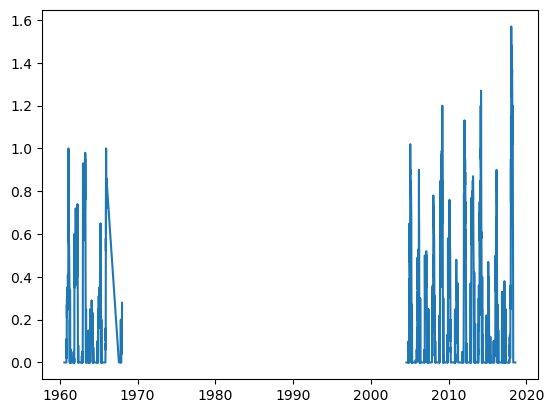

In [16]:
plt.plot(ds.time, ds.HS.sel(station = 'Zermatt'))

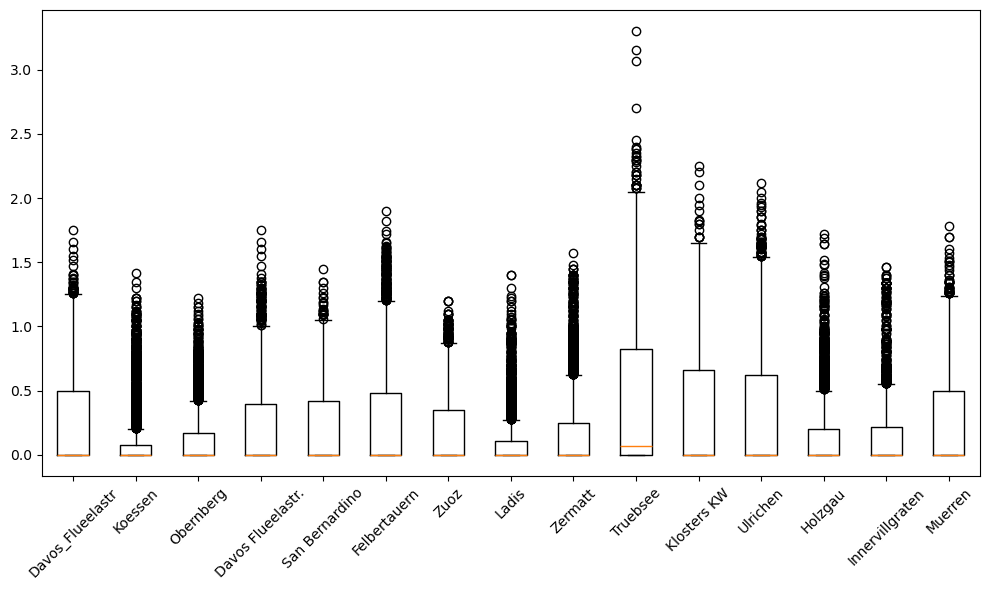

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

stations = ds.station.values

data = []
labels = []

for st in stations:
    vals = ds.hs.sel(station=st).to_numpy()
    vals = vals[np.isfinite(vals)]  # remove NaN
    
    if len(vals) == 0:
        continue  # skip empty stations
    
    data.append(vals)
    labels.append(st)

plt.figure(figsize=(10, 6))
plt.boxplot(data, tick_labels=labels)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

carefull the valuesa re still in cm --> change in R skript!!!

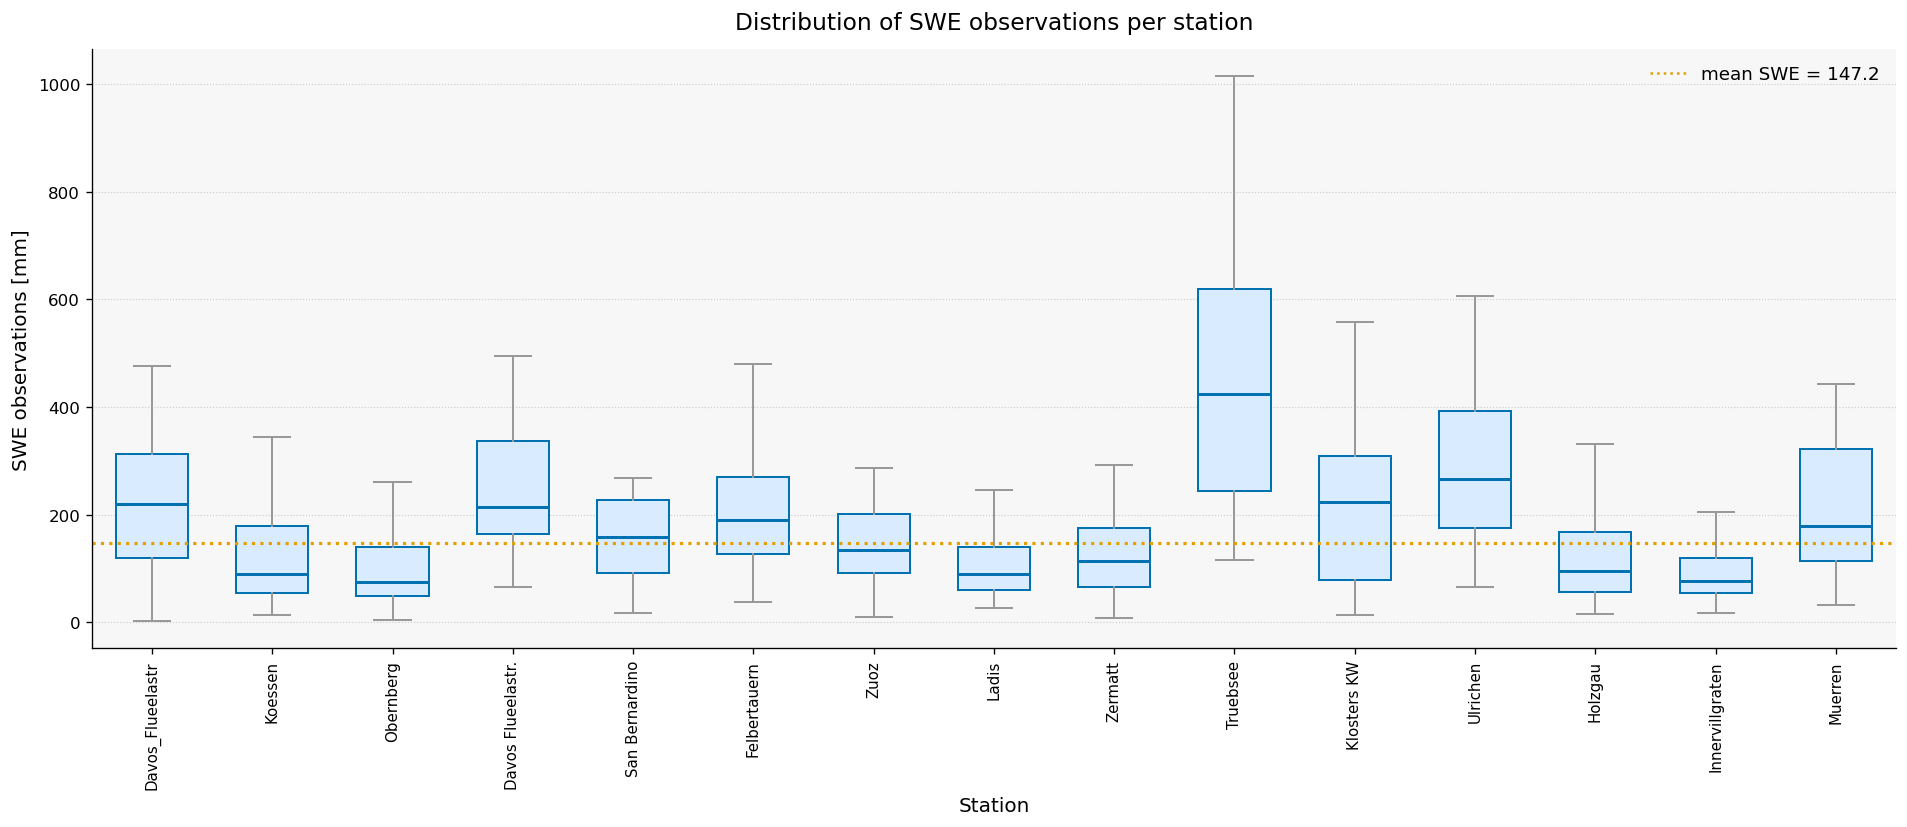

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

swe = ds["swe_obs"]
stations = ds["station"].values
swe_by_station = [swe.sel(station=st).dropna("time").values for st in stations]
mean_swe = float(swe.mean(skipna=True))

CB_BLUE   = "#0072B2"
CB_ORANGE = "#E69F00"
CB_GREEN  = "#009E73"
CB_GREY   = "#999999"

plt.style.use("default")
fig, ax = plt.subplots(figsize=(16, 7), dpi=120)
ax.set_facecolor("#F7F7F7")
fig.patch.set_facecolor("#FFFFFF")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

bp = ax.boxplot(
    swe_by_station,
    patch_artist=True,
    showfliers=False,
    widths=0.6,
    medianprops=dict(color=CB_BLUE, linewidth=1.8),
    whiskerprops=dict(color=CB_GREY, linewidth=1.2),
    capprops=dict(color=CB_GREY, linewidth=1.2),
    boxprops=dict(
        facecolor="#D9EBFF",
        edgecolor=CB_BLUE,
        linewidth=1.2
    )
)

ax.set_xticks(np.arange(1, len(stations) + 1))
ax.set_xticklabels(stations, rotation=90, fontsize=9)
ax.tick_params(axis="y", labelsize=10)

ax.set_ylabel("SWE observations [mm]", fontsize=12)  # adjust units if needed
ax.set_xlabel("Station", fontsize=12)
ax.set_title("Distribution of SWE observations per station", fontsize=14, pad=12)

ax.grid(axis="y", linestyle=":", linewidth=0.7, color="#CCCCCC")
ax.set_axisbelow(True)

ax.axhline(mean_swe, linestyle=":", linewidth=1.9, color=CB_ORANGE)

line_mean = mlines.Line2D(
    [], [], linestyle=":", color=CB_ORANGE,
    label=f"mean SWE = {mean_swe:.1f}"
)

ax.legend(handles=[line_mean], loc="upper right", frameon=False, fontsize=11)

plt.tight_layout()
plt.show()